# Final Model Fitting — Multi-Person Learning Curve Comparison

**Model:** Model A — indifference + conflict  
$\sim$: $r < \tau_r$ (low intensity → indifferent)  
$\bowtie$: $r \geq \tau_r$ and $|\kappa| \leq \tau_\kappa(r - \tau_r)$ (high intensity, balanced → conflict)

**Three response alphabets compared:**
- **2-response** $\{L,R\}$: binary choices only
- **3-response** $\{L,R,U\}$: slow RT **or** known cross-session inconsistency → observed undecided
- **4-response** $\{L,R,{\sim},{\bowtie}\}$: slow RT → observed $\bowtie$; fast + inconsistent → observed $\sim$

**Learning curve:** pool sessions 1..k for k=1..10, fit all 3 models, track near-optimal set spread (δ ≤ 1).  
**People:** 17 persons with ≥ 10 sessions. Use first 10 sessions for all.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

df = pd.read_csv('boerstler_data_labeled.csv', index_col=0)

ATTR       = ['alco', 'dep', 'life', 'crim']
DIFF_COLS  = ['alcodiff', 'depdiff', 'lifediff', 'crimdiff']
RT_COL     = 'secElasped'
RT_THR     = 20      # seconds — RT > 20s signals deliberation / conflict
DELTA_OPT  = 1.0     # near-optimal threshold (δ ≤ 1 from best score)
P_NOISE    = 0.10    # oracle noise rate (fixed)
A_NOISE    = np.log(2 * (1 - P_NOISE))   # +reward per decisive-correct
B_NOISE    = np.log(2 * P_NOISE)          # −penalty per decisive-error

print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'p_noise={P_NOISE}  A={A_NOISE:.3f}  B={B_NOISE:.3f}  C={-B_NOISE/A_NOISE:.2f}')


Dataset: 12,369 rows × 48 columns
p_noise=0.1  A=0.588  B=-1.609  C=2.74


In [2]:
# ── Normalize features ────────────────────────────────────────────────────────
RAW_MAX = np.array([
    df['alcodiff'].abs().max(),
    df['depdiff'].abs().max(),
    df['lifediff'].abs().max(),
    df['crimdiff'].abs().max(),
], dtype=float)

def get_person_data(person_id, sessions=None):
    """Return (c, d, y, rt) for a person, optionally filtered to a list of sessions."""
    mask = df['person_id'] == person_id
    if sessions is not None:
        mask &= df['session_id'].isin(sessions)
    sub = df[mask].sort_index()
    c  = sub[DIFF_COLS].values / RAW_MAX
    d  = np.abs(c)
    y  = sub['chosen'].values.astype(int)
    rt = sub[RT_COL].values.astype(float)
    return c, d, y, rt

print('RAW_MAX:', dict(zip(ATTR, RAW_MAX)))


RAW_MAX: {'alco': 4.0, 'dep': 2.0, 'life': 4.0, 'crim': 2.0}


In [3]:
# ── Core classification and counting functions ────────────────────────────────

def classify(omega, tau_r, tau_kappa, c_mat, d_mat):
    r     = d_mat @ omega
    kappa = c_mat @ omega
    wedge = tau_kappa * np.maximum(0.0, r - tau_r)
    labels = np.zeros(len(r), dtype=np.int8)
    labels[(r >= tau_r) & ( kappa > wedge)] =  1
    labels[(r >= tau_r) & (-kappa > wedge)] = -1
    return labels

def count_dc_de(labels, y):
    dc = int(((labels== 1)&(y==1)).sum() + ((labels==-1)&(y==0)).sum())
    de = int(((labels== 1)&(y==0)).sum() + ((labels==-1)&(y==1)).sum())
    return dc, de

def simplex_grid(m, k):
    def _gen(rem, dims):
        if dims == 1:
            yield (rem,)
            return
        for v in range(rem + 1):
            for rest in _gen(rem - v, dims - 1):
                yield (v,) + rest
    return np.array(list(_gen(k, m)), dtype=float) / k

OMEGA_GRID = simplex_grid(4, k=10)
TAU_K_VALS = np.arange(0, 1.0, 0.1)
print(f'Simplex grid: {len(OMEGA_GRID)} ω points  |  τ_κ values: {TAU_K_VALS}')


Simplex grid: 286 ω points  |  τ_κ values: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]


In [4]:
# ── Qualifying people (≥ 10 completed sessions) ───────────────────────────────
session_counts = df.groupby('person_id')['session_id'].nunique()
QUALIFYING = sorted(session_counts[session_counts >= 10].index.tolist())

# For each person, use only their first 10 sessions (fair comparison)
SESSIONS_USED = {}
for pid in QUALIFYING:
    all_sess = sorted(df[df['person_id']==pid]['session_id'].unique())
    SESSIONS_USED[pid] = all_sess[:10]

print(f'Qualifying people ({len(QUALIFYING)}): {QUALIFYING}')
print()
for pid in QUALIFYING:
    n = sum(df[(df['person_id']==pid) & (df['session_id'].isin(SESSIONS_USED[pid]))].shape[0]
            for _ in [1])
    n = df[(df['person_id']==pid) & (df['session_id'].isin(SESSIONS_USED[pid]))].shape[0]
    print(f'  Person {pid:>2d}: {len(SESSIONS_USED[pid])} sessions, {n} trials')


Qualifying people (17): [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 15, 16, 17, 18, 21]

  Person  0: 10 sessions, 600 trials
  Person  1: 10 sessions, 600 trials
  Person  2: 10 sessions, 590 trials
  Person  3: 10 sessions, 590 trials
  Person  4: 10 sessions, 600 trials
  Person  5: 10 sessions, 600 trials
  Person  7: 10 sessions, 600 trials
  Person  8: 10 sessions, 600 trials
  Person  9: 10 sessions, 600 trials
  Person 10: 10 sessions, 590 trials
  Person 11: 10 sessions, 540 trials
  Person 12: 10 sessions, 600 trials
  Person 15: 10 sessions, 590 trials
  Person 16: 10 sessions, 590 trials
  Person 17: 10 sessions, 540 trials
  Person 18: 10 sessions, 590 trials
  Person 21: 10 sessions, 549 trials


In [5]:
# ── Signal computation: slow and inconsistency masks ─────────────────────────
#
# slow_mask(rt):  boolean, True where RT > RT_THR (conflict signal)
#
# incon_mask_at_k(person_id, sessions_1_to_k):
#   For each unique query seen in sessions_1_to_k:
#     If that query was answered differently in ≥ 2 of those sessions
#     → mark ALL trials of that query in sessions_1_to_k as "inconsistent"
#   Returns boolean array aligned to the pooled data for sessions_1_to_k.

def slow_mask(rt):
    return rt > RT_THR

def incon_mask_at_k(person_id, sessions_k):
    """
    Boolean mask over all trials from sessions_k for person_id.
    True = this trial's query was answered inconsistently within sessions_k.
    """
    mask = (df['person_id'] == person_id) & (df['session_id'].isin(sessions_k))
    sub  = df[mask].sort_index().copy()
    sub['query'] = list(zip(*[sub[c] for c in DIFF_COLS]))

    # For each query, collect the set of choices given
    query_choices = sub.groupby('query')['chosen'].apply(set)
    # Inconsistent = query answered both ways (set has 2 elements)
    incon_queries = set(query_choices[query_choices.map(len) > 1].index)

    return sub['query'].isin(incon_queries).values.astype(bool)

# Quick check on person 0
c_chk, d_chk, y_chk, rt_chk = get_person_data(0, SESSIONS_USED[0])
sl = slow_mask(rt_chk)
ic = incon_mask_at_k(0, SESSIONS_USED[0])
print(f'Person 0 (all 10 sessions):')
print(f'  slow (RT>{RT_THR}s): {sl.sum()} trials ({100*sl.mean():.0f}%)')
print(f'  known-inconsistent:  {ic.sum()} trials ({100*ic.mean():.0f}%)')
print(f'  overlap (slow & inconsistent): {(sl & ic).sum()}')
print(f'  4-resp ⋈ (slow):         {sl.sum()}')
print(f'  4-resp ~ (fast+incon):   {(~sl & ic).sum()}')
print(f'  decisive (fast+consist): {(~sl & ~ic).sum()}')


Person 0 (all 10 sessions):
  slow (RT>20s): 93 trials (16%)
  known-inconsistent:  66 trials (11%)
  overlap (slow & inconsistent): 13
  4-resp ⋈ (slow):         93
  4-resp ~ (fast+incon):   53
  decisive (fast+consist): 454


In [6]:
# ── Noise parameters per person ───────────────────────────────────────────────
#
# C_slow : penalty per slow trial classified as decisive by model
# C_incon: penalty per fast-inconsistent trial classified as non-~ by model
#
# Both derived by fitting the 2-response model on all 10 sessions, then
# computing P(signal | model-decisive) vs P(signal | model-undecided).
# C = log(p / q)  — always negative (signal more common in undecided region).

def compute_noise_params(person_id):
    sessions = SESSIONS_USED[person_id]
    c, d, y, rt = get_person_data(person_id, sessions)
    sl = slow_mask(rt)
    ic = incon_mask_at_k(person_id, sessions)

    # Fit 2-response to get reference classification
    best_score, best_lab = -np.inf, None
    for omega in OMEGA_GRID:
        r_    = d @ omega
        kappa = c @ omega
        for tau_r in np.concatenate([[0.0], np.sort(np.unique(r_))]):
            for tau_k in TAU_K_VALS:
                w   = tau_k * np.maximum(0.0, r_ - tau_r)
                lab = np.zeros(len(y), dtype=np.int8)
                lab[(r_ >= tau_r) & ( kappa > w)] =  1
                lab[(r_ >= tau_r) & (-kappa > w)] = -1
                dc, de = count_dc_de(lab, y)
                s = dc * A_NOISE + de * B_NOISE
                if s > best_score:
                    best_score, best_lab = s, lab.copy()

    dec  = best_lab != 0
    undet = ~dec
    eps  = 1e-6   # avoid log(0)

    p_slow  = (sl & dec).sum()  / max(dec.sum(),  1)
    q_slow  = (sl & undet).sum()/ max(undet.sum(),1)
    C_slow  = np.log((p_slow + eps) / (q_slow + eps))

    # fast-inconsistent signal (inconsistent AND not slow)
    fi = ic & ~sl
    p_fi = (fi & dec).sum()  / max(dec.sum(),  1)
    q_fi = (fi & undet).sum()/ max(undet.sum(),1)
    C_incon = np.log((p_fi + eps) / (q_fi + eps))

    # Clip to non-positive: C should penalize mismatches, never reward.
    # Positive C happens when a person is so decisive that the signal
    # correlates more with the decisive region — in that case the signal
    # is uninformative, so use 0 (no penalty, no reward).
    C_slow  = min(C_slow,  0.0)
    C_incon = min(C_incon, 0.0)
    return dict(C_slow=C_slow, C_incon=C_incon,
                best_score=best_score, n_dec=dec.sum(), n_undet=undet.sum())

print('Computing noise params for all qualifying people...')
t0 = time.time()
NOISE = {}
for pid in QUALIFYING:
    NOISE[pid] = compute_noise_params(pid)

print(f'Done ({time.time()-t0:.0f}s)')
print()
print(f'  {"pid":>5}  {"C_slow":>8}  {"C_incon":>9}  {"n_dec":>6}  {"n_undet":>8}  {"best_score":>11}')
print('  ' + '-'*55)
for pid in QUALIFYING:
    p = NOISE[pid]
    print(f'  {pid:>5}  {p["C_slow"]:>8.3f}  {p["C_incon"]:>9.3f}  '
          f'{p["n_dec"]:>6}  {p["n_undet"]:>8}  {p["best_score"]:>11.2f}')


Computing noise params for all qualifying people...
Done (38s)

    pid    C_slow    C_incon   n_dec   n_undet   best_score
  -------------------------------------------------------
      0    -0.392     -0.637     283       317        56.48
      1     0.000     -1.563     538        62       232.73
      2    -0.148    -12.877     434       156       255.10
      3    -0.101      0.000     377       213       100.75
      4    -0.600    -10.098      65       535        38.21
      5    -0.841     -1.214     436       164       216.72
      7    -0.385    -11.368      68       532        39.97
      8     0.000     -0.857     460       140       160.52
      9    -0.767    -11.368      80       520        36.04
     10    -0.187     -1.050     374       216        77.01
     11    -0.241     -0.433     377       163       107.34
     12    -0.756     -1.512     478       122       223.83
     15    -0.252    -12.180     436       154       256.27
     16    -0.327     -1.426     106  

In [7]:
# ── Three fitting functions (return sorted list of scored triples) ────────────

def _base_classify(omega, c, d, tau_r, tau_k):
    r     = d @ omega
    kappa = c @ omega
    w     = tau_k * np.maximum(0.0, r - tau_r)
    lab   = np.zeros(len(r), dtype=np.int8)
    lab[(r >= tau_r) & ( kappa > w)] =  1
    lab[(r >= tau_r) & (-kappa > w)] = -1
    return lab, r, kappa, w


def fit_2resp(c, d, y):
    """2-response: score all trials as binary decisive/undecided."""
    results = []
    for omega in OMEGA_GRID:
        r_ = d @ omega
        for tau_r in np.concatenate([[0.0], np.sort(np.unique(r_))]):
            for tau_k in TAU_K_VALS:
                lab, _, _, _ = _base_classify(omega, c, d, tau_r, tau_k)
                dc, de = count_dc_de(lab, y)
                results.append((dc*A_NOISE + de*B_NOISE, omega.copy(), tau_r, tau_k))
    results.sort(key=lambda x: -x[0])
    return results


def fit_3resp(c, d, y, slow, incon, C_u):
    """
    3-response: observed-undecided = slow OR inconsistent.
    Score decisive trials normally; penalize observed-undecided called decisive.
    C_u  : penalty per observed-undecided trial that model calls decisive.
    """
    obs_undet = slow | incon
    obs_dec   = ~obs_undet
    results   = []
    for omega in OMEGA_GRID:
        r_ = d @ omega
        for tau_r in np.concatenate([[0.0], np.sort(np.unique(r_))]):
            for tau_k in TAU_K_VALS:
                lab, _, _, _ = _base_classify(omega, c, d, tau_r, tau_k)
                dec = lab != 0
                # Score on observed-decisive trials only
                dc, de = count_dc_de(lab[obs_dec], y[obs_dec])
                # Penalize observed-undecided trials the model calls decisive
                n_wrong = int((obs_undet & dec).sum())
                score   = dc*A_NOISE + de*B_NOISE + n_wrong*C_u
                results.append((score, omega.copy(), tau_r, tau_k))
    results.sort(key=lambda x: -x[0])
    return results


def fit_4resp(c, d, y, slow, incon, C_slow, C_incon):
    """
    4-response: slow → observed ⋈; fast+inconsistent → observed ~.
    Penalize:
      slow trial NOT in ⋈ zone  (r < tau_r OR outside wedge but decisive)
      fast+incon trial NOT in ~ zone  (r >= tau_r)
    """
    obs_conf  = slow                  # observed ⋈
    obs_indf  = incon & ~slow         # observed ~
    obs_dec   = ~slow & ~incon        # observed decisive
    results   = []
    for omega in OMEGA_GRID:
        r_ = d @ omega
        kp = c @ omega
        for tau_r in np.concatenate([[0.0], np.sort(np.unique(r_))]):
            for tau_k in TAU_K_VALS:
                lab, r, kappa, w = _base_classify(omega, c, d, tau_r, tau_k)
                dec = lab != 0

                # Score observed-decisive trials
                dc, de = count_dc_de(lab[obs_dec], y[obs_dec])

                # Penalize slow trials NOT in conflict zone (⋈ zone: r>=tau_r AND |κ|<=w AND undecided)
                in_conf = (r >= tau_r) & (np.abs(kappa) <= w) & ~dec
                n_slow_wrong  = int((obs_conf & ~in_conf).sum())

                # Penalize fast-incon trials NOT in ~ zone (~ zone: r < tau_r)
                in_indf = r < tau_r
                n_indf_wrong  = int((obs_indf & ~in_indf).sum())

                score = (dc*A_NOISE + de*B_NOISE
                         + n_slow_wrong  * C_slow
                         + n_indf_wrong  * C_incon)
                results.append((score, omega.copy(), tau_r, tau_k))
    results.sort(key=lambda x: -x[0])
    return results


In [8]:
# ── Near-optimal set statistics ───────────────────────────────────────────────

def near_opt_stats(results, delta=DELTA_OPT):
    """
    Compute spread statistics for all parameter triples within delta of the best.
    Returns a dict with n, tau_r range, tau_k range, omega_std per attribute.
    """
    if not results:
        return None
    best = results[0][0]
    near = [(s, om, tr, tk) for s, om, tr, tk in results if best - s <= delta]
    omegas = np.array([om for _, om, _, _ in near])
    taus_r = np.array([tr for _, _, tr, _ in near])
    taus_k = np.array([tk for _, _, _, tk in near])
    return dict(
        n        = len(near),
        best     = best,
        tr_lo    = taus_r.min(),
        tr_hi    = taus_r.max(),
        tk_lo    = taus_k.min(),
        tk_hi    = taus_k.max(),
        tr_range = taus_r.max() - taus_r.min(),
        tk_range = taus_k.max() - taus_k.min(),
        om_std   = omegas.std(axis=0),
        best_tr  = results[0][2],
        best_tk  = results[0][3],
        best_om  = results[0][1],
    )


In [9]:
# ── Learning curve for one person ─────────────────────────────────────────────
#
# For k = 1..10: pool sessions 1..k, compute signals, fit all 3 models.
# Returns list of dicts, one per k.

def learning_curve_person(person_id, verbose=False):
    sessions = SESSIONS_USED[person_id]
    C_slow  = NOISE[person_id]['C_slow']
    C_incon = NOISE[person_id]['C_incon']

    curve = []
    for k in range(1, len(sessions) + 1):
        sess_k = sessions[:k]
        c, d, y, rt = get_person_data(person_id, sess_k)
        sl   = slow_mask(rt)
        ic   = incon_mask_at_k(person_id, sess_k)
        n    = len(y)

        r2 = fit_2resp(c, d, y)
        r3 = fit_3resp(c, d, y, sl, ic, C_slow)   # use C_slow as generic undecided penalty
        r4 = fit_4resp(c, d, y, sl, ic, C_slow, C_incon)

        s2 = near_opt_stats(r2)
        s3 = near_opt_stats(r3)
        s4 = near_opt_stats(r4)

        rec = dict(k=k, n=n,
                   n_slow=int(sl.sum()), n_incon=int(ic.sum()),
                   stats2=s2, stats3=s3, stats4=s4)
        curve.append(rec)

        if verbose:
            print(f'  k={k:>2d} n={n:>3d}  '
                  f'2r: score={s2["best"]:>6.2f} n*={s2["n"]:>4} tr=[{s2["tr_lo"]:.2f},{s2["tr_hi"]:.2f}]  |  '
                  f'3r: score={s3["best"]:>6.2f} n*={s3["n"]:>4} tr=[{s3["tr_lo"]:.2f},{s3["tr_hi"]:.2f}]  |  '
                  f'4r: score={s4["best"]:>6.2f} n*={s4["n"]:>4} tr=[{s4["tr_lo"]:.2f},{s4["tr_hi"]:.2f}]')
    return curve


# ── Quick demo: person 0 ───────────────────────────────────────────────────────
print('Person 0 demo:')
print(f'  {"k":>3}  {"n":>4}  {"slow":>5}  {"incon":>6}  '
      f'{"2r score":>9}  {"2r n*":>6}  {"2r τ_r range":>14}  |  '
      f'{"4r score":>9}  {"4r n*":>6}  {"4r τ_r range":>14}')
print('  ' + '-'*100)
t0 = time.time()
lc_demo = learning_curve_person(0, verbose=False)
for rec in lc_demo:
    s2, s4 = rec['stats2'], rec['stats4']
    print(f'  {rec["k"]:>3}  {rec["n"]:>4}  {rec["n_slow"]:>5}  {rec["n_incon"]:>6}  '
          f'{s2["best"]:>9.2f}  {s2["n"]:>6}  '
          f'[{s2["tr_lo"]:.2f},{s2["tr_hi"]:.2f}]         |  '
          f'{s4["best"]:>9.2f}  {s4["n"]:>6}  '
          f'[{s4["tr_lo"]:.2f},{s4["tr_hi"]:.2f}]')
print(f'  Person 0 done in {time.time()-t0:.0f}s')


Person 0 demo:
    k     n   slow   incon   2r score   2r n*    2r τ_r range  |   4r score   4r n*    4r τ_r range
  ----------------------------------------------------------------------------------------------------
    1    60      9       0      10.73      30  [0.60,0.68]         |       6.89      65  [0.28,0.70]
    2   120     14       0      16.26       9  [0.12,0.35]         |      13.18      11  [0.12,0.35]
    3   180     24       4      25.41       9  [0.23,0.35]         |      19.62       4  [0.28,0.30]
    4   240     36      10      20.46      12  [0.35,0.50]         |      12.70      16  [0.30,0.50]
    5   300     42      12      24.74      14  [0.65,0.70]         |      16.69       6  [0.30,0.35]
    6   360     55      14      32.29      11  [0.30,0.70]         |      17.92       5  [0.30,0.35]
    7   420     65      24      36.90      13  [0.45,0.68]         |      15.17      10  [0.45,0.50]
    8   480     72      39      38.64      41  [0.45,0.70]         |      1

In [10]:
# ── Run learning curve for all qualifying people ──────────────────────────────
# Expected runtime: ~3-5 minutes total.

ALL_CURVES = {}
t_total = time.time()

for pid in QUALIFYING:
    t0 = time.time()
    ALL_CURVES[pid] = learning_curve_person(pid)
    print(f'Person {pid:>2d}: done in {time.time()-t0:.0f}s')

print(f'\nAll done in {time.time()-t_total:.0f}s')


Person  0: done in 1121s
Person  1: done in 78s
Person  2: done in 77s
Person  3: done in 2725s
Person  4: done in 86s
Person  5: done in 76s
Person  7: done in 75s
Person  8: done in 76s
Person  9: done in 75s
Person 10: done in 75s
Person 11: done in 72s
Person 12: done in 75s
Person 15: done in 75s
Person 16: done in 75s
Person 17: done in 74s
Person 18: done in 98s
Person 21: done in 82s

All done in 5014s


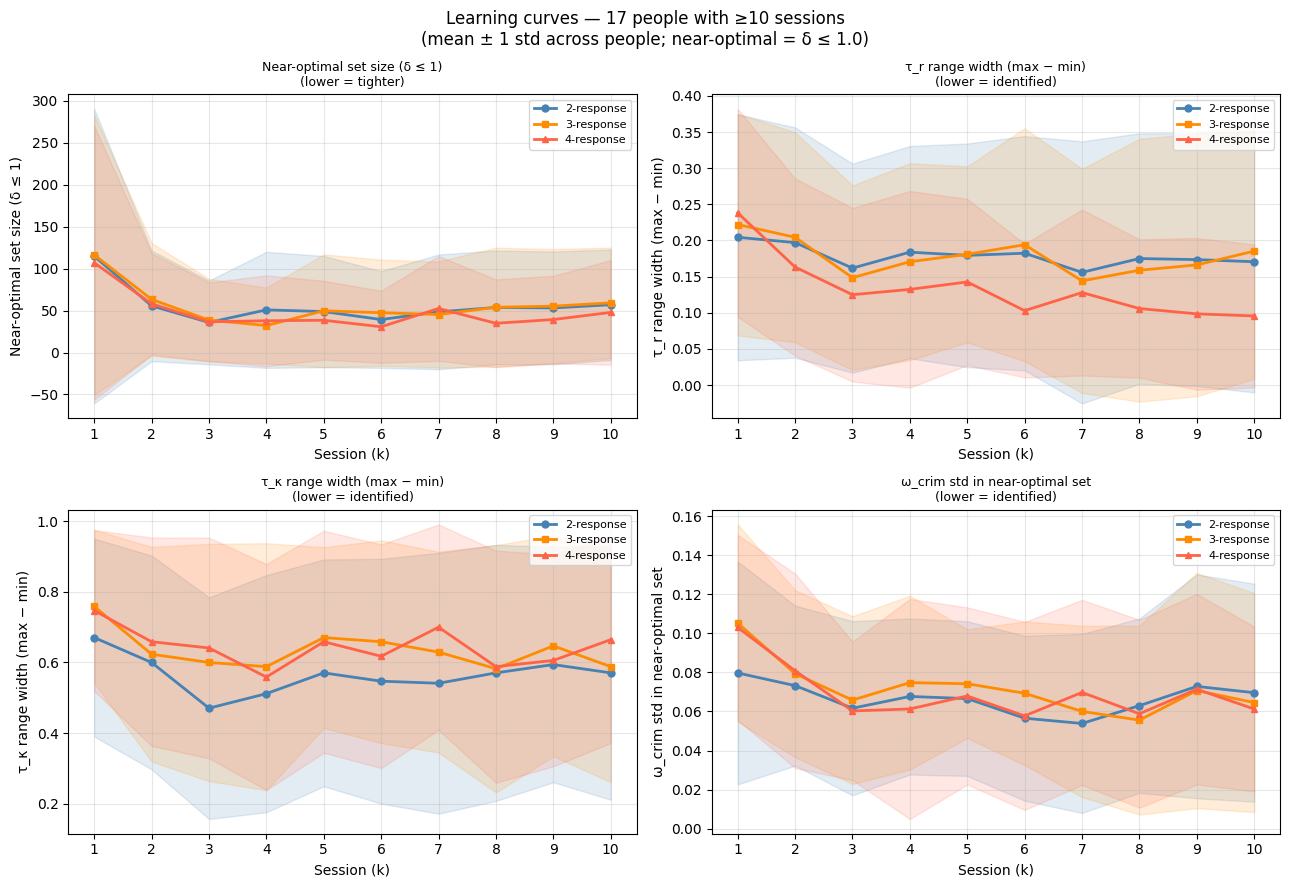

In [11]:
# ── Average learning curves across all qualifying people ──────────────────────
#
# For each session k, collect stats across all people and compute mean ± std.
# Plots: (1) near-optimal set size, (2) τ_r range, (3) τ_κ range, (4) ω_crim std

N_SESS = 10
models  = ['2resp', '3resp', '4resp']
colors  = {'2resp': 'steelblue', '3resp': 'darkorange', '4resp': 'tomato'}
markers = {'2resp': 'o', '3resp': 's', '4resp': '^'}
labels  = {'2resp': '2-response', '3resp': '3-response', '4resp': '4-response'}
stat_keys = ['stats2', 'stats3', 'stats4']
model_map = dict(zip(stat_keys, models))

# Build arrays: shape (n_people, n_sessions) for each metric
def collect(metric):
    """Return dict of arrays {model: shape (n_people, N_SESS)}."""
    out = {m: np.full((len(QUALIFYING), N_SESS), np.nan) for m in models}
    for pi, pid in enumerate(QUALIFYING):
        curve = ALL_CURVES[pid]
        for rec in curve:
            ki = rec['k'] - 1
            if ki >= N_SESS:
                continue
            for sk, m in model_map.items():
                s = rec[sk]
                if s is not None and metric in s:
                    v = s[metric]
                    if isinstance(v, np.ndarray):
                        v = float(v[3])   # omega_std: index 3 = crim
                    out[m][pi, ki] = float(v)
    return out

n_trials_per_k = np.array([60*k for k in range(1, N_SESS+1)])
# Use session number as x-axis
x_axis = np.arange(1, N_SESS+1)

metrics = [
    ('n',       'Near-optimal set size (δ ≤ 1)',         'lower = tighter'),
    ('tr_range','τ_r range width (max − min)',            'lower = identified'),
    ('tk_range','τ_κ range width (max − min)',            'lower = identified'),
    ('om_std',  'ω_crim std in near-optimal set',         'lower = identified'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    f'Learning curves — {len(QUALIFYING)} people with ≥10 sessions\n'
    f'(mean ± 1 std across people; near-optimal = δ ≤ {DELTA_OPT})',
    fontsize=12)

for ax, (mk, title, note) in zip(axes.flat, metrics):
    data = collect(mk)
    for m in models:
        arr = data[m]   # (n_people, N_SESS)
        mu  = np.nanmean(arr, axis=0)
        sd  = np.nanstd(arr,  axis=0)
        ax.plot(x_axis, mu, color=colors[m], marker=markers[m],
                label=labels[m], linewidth=2, markersize=5)
        ax.fill_between(x_axis, mu-sd, mu+sd,
                        color=colors[m], alpha=0.15)
    ax.set_xlabel('Session (k)', fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(f'{title}\n({note})', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(x_axis)

plt.tight_layout()
plt.show()


In [12]:
# ── Summary table: per-person best-fit parameters at k=10 ────────────────────

print(f'Best-fit parameters at k=10 (all 10 sessions):')
print(f'  {"pid":>5}  {"2r τ_r":>7}  {"2r τ_κ":>7}  {"2r score":>9}  |  '
      f'{"3r τ_r":>7}  {"3r τ_κ":>7}  {"3r score":>9}  |  '
      f'{"4r τ_r":>7}  {"4r τ_κ":>7}  {"4r score":>9}')
print('  ' + '-'*90)

for pid in QUALIFYING:
    rec = ALL_CURVES[pid][-1]   # k=10
    s2, s3, s4 = rec['stats2'], rec['stats3'], rec['stats4']
    print(f'  {pid:>5}  '
          f'{s2["best_tr"]:>7.3f}  {s2["best_tk"]:>7.1f}  {s2["best"]:>9.2f}  |  '
          f'{s3["best_tr"]:>7.3f}  {s3["best_tk"]:>7.1f}  {s3["best"]:>9.2f}  |  '
          f'{s4["best_tr"]:>7.3f}  {s4["best_tk"]:>7.1f}  {s4["best"]:>9.2f}')

print()
print('Average across people:')
for sk, m in [('stats2','2-resp'), ('stats3','3-resp'), ('stats4','4-resp')]:
    trs = [ALL_CURVES[pid][-1][sk]['best_tr'] for pid in QUALIFYING]
    tks = [ALL_CURVES[pid][-1][sk]['best_tk'] for pid in QUALIFYING]
    scs = [ALL_CURVES[pid][-1][sk]['best']    for pid in QUALIFYING]
    print(f'  {m}: τ_r = {np.mean(trs):.3f} ± {np.std(trs):.3f}   '
          f'τ_κ = {np.mean(tks):.2f} ± {np.std(tks):.2f}   '
          f'score = {np.mean(scs):.1f} ± {np.std(scs):.1f}')


Best-fit parameters at k=10 (all 10 sessions):
    pid   2r τ_r   2r τ_κ   2r score  |   3r τ_r   3r τ_κ   3r score  |   4r τ_r   4r τ_κ   4r score
  ------------------------------------------------------------------------------------------
      0    0.475      0.8      56.48  |    0.500      0.8      52.38  |    0.475      0.8      26.77
      1    0.100      0.3     232.73  |    0.100      0.3     224.65  |    0.400      0.0     123.40
      2    0.200      0.0     255.10  |    0.200      0.0     246.27  |    0.250      0.0     245.53
      3    0.350      0.9     100.75  |    0.350      0.2     115.59  |    0.350      0.2     119.13
      4    0.950      0.0      38.21  |    0.950      0.0      37.02  |    0.950      0.0      28.02
      5    0.000      0.0     216.72  |    0.000      0.0     156.69  |    0.000      0.0     128.03
      7    1.000      0.0      39.97  |    0.725      0.7      38.13  |    0.800      0.0      20.93
      8    0.150      0.4     160.52  |    0.100    

## Interpretation

**Reading the learning curves:**
- A **faster-dropping** curve means parameters are identified from fewer sessions.
- The 4-response model should converge earliest because it gets two signals from the start: RT identifies $\bowtie$ (from session 1), and inconsistency identifies $\sim$ (builds from session 2+).
- The 3-response model gets both signals pooled (RT or inconsistency → generic undecided), so $\tau_r$ vs $\tau_\kappa$ identification is weaker.
- The 2-response model only gets information through cross-session inconsistency in the label vector, which accumulates slowly.

**If 4-response converges in ~3 sessions while 2-response needs ~9:**  
A well-designed elicitation that records response times provides ~3× data efficiency. For the paper: the RT signal alone (available from session 1) is the dominant driver; the incremental inconsistency signal is a smaller bonus.

**Cross-person spread:**  
Large shaded bands indicate people with qualitatively different response behavior. A narrow band would mean the model parameters are stable across people.
